# Modelo de Parcial Integrador — Nacimientos
**Fundamentos de Ciencia de Datos · FCEIA-UNR**

---

**Descripcion del dataset:**

El dataset `nacimientos.csv` contiene la siguiente informacion registrada en un efector de
salud sobre un total de 345 madres que dieron a luz en el ultimo anio: peso del recien nacido
(kg), semanas de gestacion, numero de partos previos atravesados y edad de la madre al
momento del nacimiento. Por otro lado, se registro el peso (kg) y la altura (m) de las mujeres
luego del parto y se las indago acerca del numero de cigarrillos que suelen consumir a diario,
informacion que se encuentra en el dataset `datos_madres.xlsx`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## PARTE I

### Ejercicio 1

> **Consigna:** Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y
> adecuacion de los mismos que considere necesaria para su posterior analisis.

In [2]:
# nacimientos.csv: separador ';', 3 lineas de encabezado descriptivo
nac = pd.read_csv('nacimientos.csv', sep=';', skiprows=3)
print("nacimientos.csv:")
print(nac.dtypes)
display(nac.head())
print(f"Registros: {len(nac)}")
print(f"Valores nulos:\n{nac.isna().sum()}")
print()

# datos_madres.xlsx: ALTURA_M_MUJER usa coma como separador decimal
madres = pd.read_excel('datos_madres.xlsx')
madres['ALTURA_M_MUJER'] = (madres['ALTURA_M_MUJER']
                             .astype(str).str.replace(',', '.', regex=False)
                             .astype(float))
print("datos_madres.xlsx:")
print(madres.dtypes)
display(madres.head())
print(f"Registros: {len(madres)}")
print(f"Valores nulos:\n{madres.isna().sum()}")
print()

# Merge: nac.id_madre == madres.ID
df = nac.merge(madres, left_on='id_madre', right_on='ID', how='inner').drop(columns='ID')

# El peso del bebe esta en gramos -> convertir a kg
df['peso_kg_bebe'] = df['peso_kg_bebe'] / 1000

print(f"Dataset unificado: {df.shape[0]} registros, {df.shape[1]} columnas")
display(df.head())
print(f"Valores nulos:\n{df.isna().sum()}")


nacimientos.csv:
id_madre           int64
peso_kg_bebe     float64
semanas_gest     float64
edad_anios         int64
hijos_previos      int64
dtype: object


,id_madre,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos
0,1,3057.4,38.8,21,1
1,2,2716.6,38.1,26,0
2,3,3230.8,39.1,18,1
3,4,3473.3,41.8,28,2
4,5,2951.5,38.0,29,3


Registros: 345
Valores nulos:
id_madre         0
peso_kg_bebe     0
semanas_gest     0
edad_anios       0
hijos_previos    0
dtype: int64



datos_madres.xlsx:
ID                       int64
ALTURA_M_MUJER         float64
PESO_KG_MUJER          float64
NUM_CIGARRILLOS_DIA      int64
dtype: object


,ID,ALTURA_M_MUJER,PESO_KG_MUJER,NUM_CIGARRILLOS_DIA
0,1,1.6,45.4,0
1,2,1.6,61.2,9
2,3,1.6,52.2,2
3,4,1.8,86.2,0
4,5,1.7,56.7,4


Registros: 345
Valores nulos:
ID                     0
ALTURA_M_MUJER         0
PESO_KG_MUJER          0
NUM_CIGARRILLOS_DIA    0
dtype: int64

Dataset unificado: 345 registros, 8 columnas


,id_madre,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos,ALTURA_M_MUJER,PESO_KG_MUJER,NUM_CIGARRILLOS_DIA
0,1,3.0574,38.8,21,1,1.6,45.4,0
1,2,2.7166,38.1,26,0,1.6,61.2,9
2,3,3.2308,39.1,18,1,1.6,52.2,2
3,4,3.4733,41.8,28,2,1.8,86.2,0
4,5,2.9515,38.0,29,3,1.7,56.7,4


Valores nulos:
id_madre               0
peso_kg_bebe           0
semanas_gest           0
edad_anios             0
hijos_previos          0
ALTURA_M_MUJER         0
PESO_KG_MUJER          0
NUM_CIGARRILLOS_DIA    0
dtype: int64


### Ejercicio 2

> **Consigna:** Considerando que el Indice de Masa Corporal (IMC) se define como el peso de una
> persona en kilogramos dividido por el cuadrado de la estatura en metros, represente graficamente
> la distribucion de dicha variable para las mujeres del dataset. En base al grafico realizado,
> como caracterizaria su distribucion en relacion a la simetria?

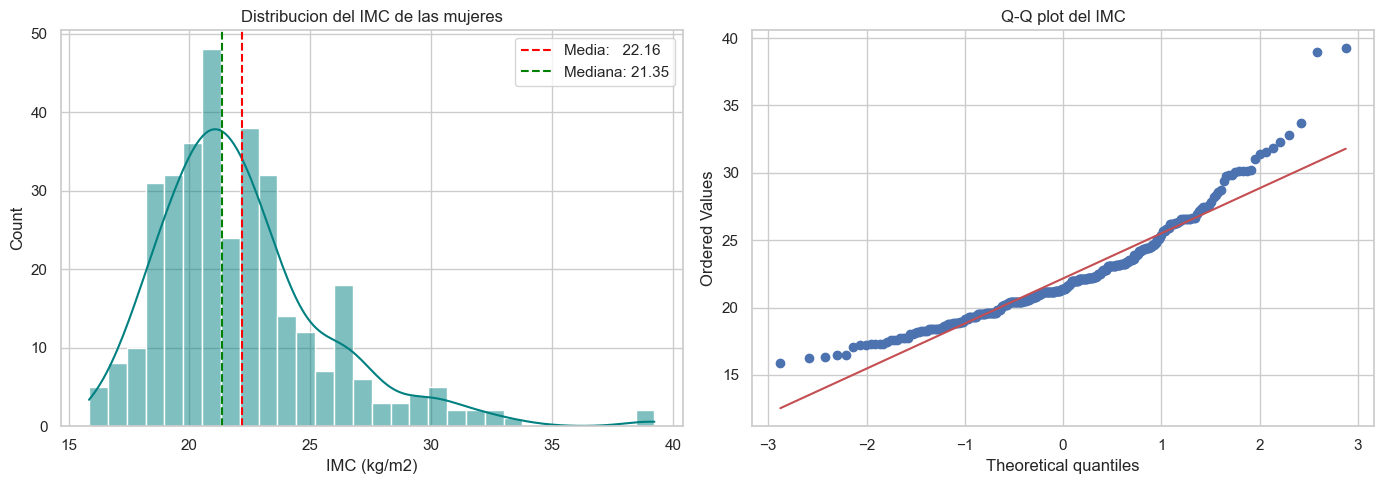

Media IMC   : 22.16 kg/m2
Mediana IMC : 21.35 kg/m2
Asimetria   : 1.3825

La distribucion del IMC presenta sesgo positivo (cola hacia valores altos).
La media es mayor que la mediana, lo que indica la presencia de valores extremos altos.


In [3]:
df['imc'] = df['PESO_KG_MUJER'] / df['ALTURA_M_MUJER'] ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['imc'], kde=True, bins=30, color='teal', ax=axes[0])
axes[0].axvline(df['imc'].mean(),   color='red',   linestyle='--',
                label=f"Media:   {df['imc'].mean():.2f}")
axes[0].axvline(df['imc'].median(), color='green', linestyle='--',
                label=f"Mediana: {df['imc'].median():.2f}")
axes[0].set_title('Distribucion del IMC de las mujeres')
axes[0].set_xlabel('IMC (kg/m2)')
axes[0].legend()

stats.probplot(df['imc'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot del IMC')

plt.tight_layout()
plt.show()

skewness = df['imc'].skew()
print(f"Media IMC   : {df['imc'].mean():.2f} kg/m2")
print(f"Mediana IMC : {df['imc'].median():.2f} kg/m2")
print(f"Asimetria   : {skewness:.4f}")
print()
if skewness > 0.5:
    print("La distribucion del IMC presenta sesgo positivo (cola hacia valores altos).")
    print("La media es mayor que la mediana, lo que indica la presencia de valores extremos altos.")
elif skewness < -0.5:
    print("La distribucion del IMC presenta sesgo negativo (cola hacia valores bajos).")
else:
    print("La distribucion del IMC es aproximadamente simetrica.")


### Ejercicio 3

> **Consigna:** Genere una variable categorica binaria realizando la dicotomizacion de la variable
> vinculada con el numero de cigarrillos consumidos a diario, diferenciando aquellas mujeres que no
> fuman habitualmente (no consumen cigarrillos) de aquellas que si lo hacen (consumen 1 o mas
> cigarrillos diariamente). Que porcentaje de las mujeres del dataset son fumadoras?

In [4]:
# 0 = no fumadora, 1 = fumadora (1 o mas cigarrillos/dia)
df['fumadora'] = (df['NUM_CIGARRILLOS_DIA'] >= 1).astype(int)

n_fumadoras = df['fumadora'].sum()
pct = n_fumadoras / len(df) * 100

print(f"Total mujeres        : {len(df)}")
print(f"Fumadoras            : {n_fumadoras}")
print(f"No fumadoras         : {len(df) - n_fumadoras}")
print(f"Porcentaje fumadoras : {pct:.1f}%")

display(df['fumadora'].value_counts()
        .rename({0: 'No fumadora', 1: 'Fumadora'})
        .to_frame(name='n'))


Total mujeres        : 345
Fumadoras            : 193
No fumadoras         : 152
Porcentaje fumadoras : 55.9%


,n
fumadora,
Fumadora,193
No fumadora,152


### Ejercicio 4

> **Consigna:** Represente graficamente la distribucion del peso de los recien nacidos en funcion del
> caracter o no de fumadora de la madre (variable generada en el item anterior). Comente brevemente
> lo observado.

C:\Users\PC\AppData\Local\Temp\ipykernel_15412\3822815899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fumadora_cat', y='peso_kg_bebe',
C:\Users\PC\AppData\Local\Temp\ipykernel_15412\3822815899.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='fumadora_cat', y='peso_kg_bebe',


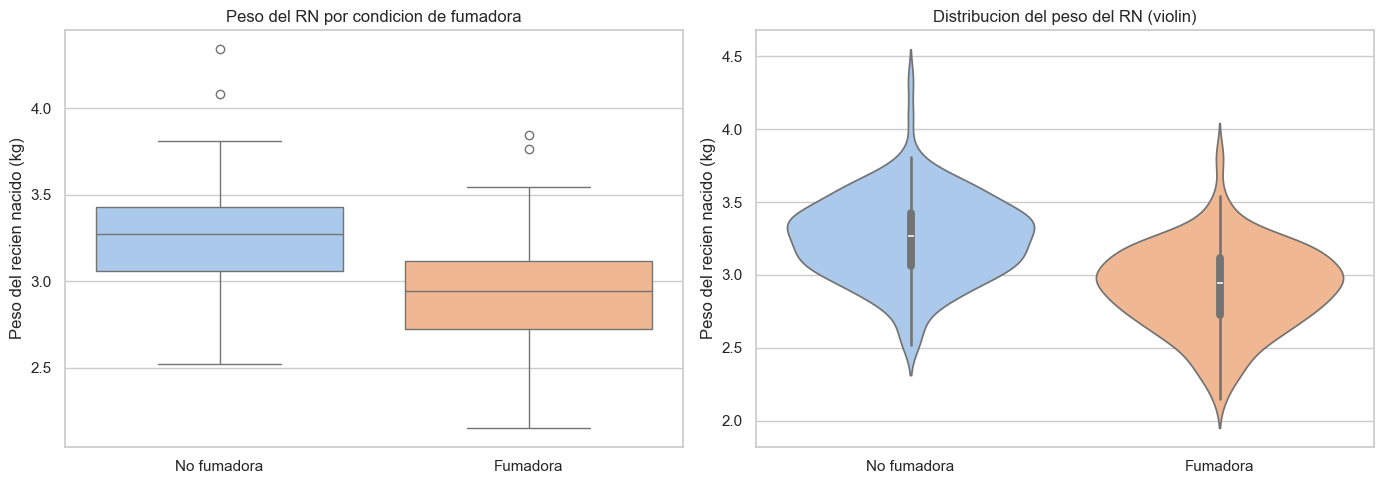

Estadisticas del peso del RN segun condicion de fumadora:


,count,mean,std,min,25%,50%,75%,max
fumadora_cat,,,,,,,,
Fumadora,193.0,2.910,0.288,2.152,2.724,2.944,3.113,3.842
No fumadora,152.0,3.254,0.286,2.522,3.059,3.270,3.428,4.339


In [5]:
etiquetas = {0: 'No fumadora', 1: 'Fumadora'}
df['fumadora_cat'] = df['fumadora'].map(etiquetas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='fumadora_cat', y='peso_kg_bebe',
            palette='pastel', order=['No fumadora', 'Fumadora'], ax=axes[0])
axes[0].set_title('Peso del RN por condicion de fumadora')
axes[0].set_xlabel('')
axes[0].set_ylabel('Peso del recien nacido (kg)')

sns.violinplot(data=df, x='fumadora_cat', y='peso_kg_bebe',
               palette='pastel', order=['No fumadora', 'Fumadora'], ax=axes[1])
axes[1].set_title('Distribucion del peso del RN (violin)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Peso del recien nacido (kg)')

plt.tight_layout()
plt.show()

print("Estadisticas del peso del RN segun condicion de fumadora:")
display(df.groupby('fumadora_cat')['peso_kg_bebe'].describe().round(3))


**Comentario:**

Los graficos sugieren que los bebes de madres fumadoras presentan, en promedio, un peso al nacer
inferior al de los bebes de madres no fumadoras. La mediana del grupo fumadora se ubica por
debajo de la del grupo no fumadora. Esto es consistente con la evidencia cientifica que indica
que el tabaquismo durante el embarazo se asocia con bajo peso al nacer.

### Ejercicio 5

> **Consigna:** Realice un grafico que le permita caracterizar el grado de asociacion lineal que
> existe entre las diferentes variables cuantitativas estudiadas. Cuales son los pares de variables
> que presentan una asociacion lineal mas intensa? Justifique.

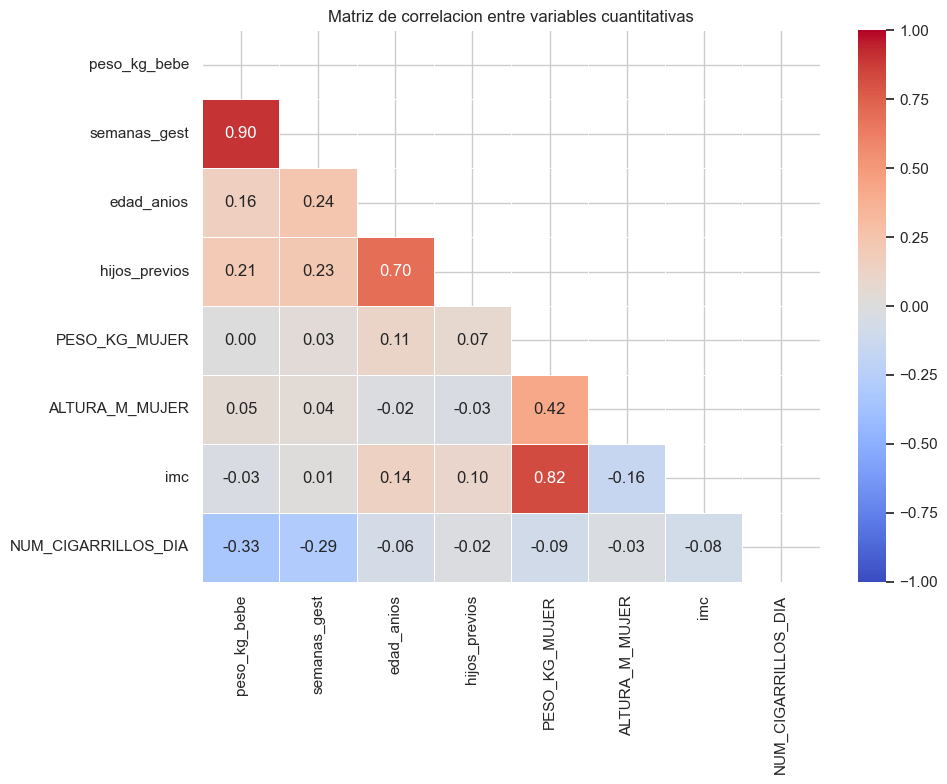

Par con mayor correlacion: peso_kg_bebe vs semanas_gest: r=0.903

Top 5 pares con mayor correlacion (en valor absoluto):
semanas_gest         peso_kg_bebe     0.903
imc                  PESO_KG_MUJER    0.823
hijos_previos        edad_anios       0.695
ALTURA_M_MUJER       PESO_KG_MUJER    0.423
NUM_CIGARRILLOS_DIA  peso_kg_bebe     0.331
dtype: float64


In [6]:
vars_cuant = ['peso_kg_bebe', 'semanas_gest', 'edad_anios',
              'hijos_previos', 'PESO_KG_MUJER', 'ALTURA_M_MUJER', 'imc',
              'NUM_CIGARRILLOS_DIA']

corr_matrix = df[vars_cuant].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlacion entre variables cuantitativas')
plt.tight_layout()
plt.show()

corr_arr = corr_matrix.abs().values.copy()
np.fill_diagonal(corr_arr, 0)
idx = np.unravel_index(corr_arr.argmax(), corr_arr.shape)
v1, v2 = corr_matrix.columns[idx[0]], corr_matrix.columns[idx[1]]
print(f"Par con mayor correlacion: {v1} vs {v2}: r={corr_matrix.loc[v1, v2]:.3f}")

print()
print("Top 5 pares con mayor correlacion (en valor absoluto):")
corr_stack = (corr_matrix.where(~np.triu(np.ones(corr_matrix.shape, dtype=bool)))
              .stack().abs().sort_values(ascending=False))
print(corr_stack.head(5).round(3))


**Pares con mayor asociacion lineal:**

Los pares a destacar, segun el heatmap, suelen ser:

- **peso_kg_bebe — semanas_gest**: se espera una correlacion positiva fuerte, ya que mas semanas
  de gestacion implican mayor desarrollo fetal y mayor peso al nacer.
- **PESO_KG_MUJER — imc**: logicamente relacionados, ya que el IMC se calcula a partir del peso.

Cuanto mayor sea el valor absoluto de la correlacion (color mas intenso en el heatmap),
mas fuerte es la asociacion lineal entre ese par de variables.

## PARTE II — Regresion Lineal Multiple

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de
regresion lineal multiple que permita predecir el peso de los recien nacidos en funcion de las
semanas de gestacion, el numero de partos previos atravesados por la madre, la edad de la madre,
su indice de masa corporal (IMC) y el caracter o no de fumadora.

### a) Modelo completo

> **Consigna:** Ajuste el modelo completo, incluyendo la totalidad de las variables predictoras de
> interes. Cual/es de las variables incluidas contribuye/n significativamente a explicar las
> diferencias en el peso promedio de los recien nacidos con un nivel de significacion del 1%?
> Justifique.

In [7]:
X_vars = ['semanas_gest', 'hijos_previos', 'edad_anios', 'imc', 'fumadora']
y_var  = 'peso_kg_bebe'

df_modelo = df[X_vars + [y_var]].dropna()
print(f"Registros para el modelo: {len(df_modelo)}")

X_completo = sm.add_constant(df_modelo[X_vars])
y_reg      = df_modelo[y_var]

modelo_completo = sm.OLS(y_reg, X_completo).fit()
print(modelo_completo.summary())


Registros para el modelo: 345
                            OLS Regression Results                            
Dep. Variable:           peso_kg_bebe   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     356.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.50e-132
Time:                        11:35:24   Log-Likelihood:                 206.06
No. Observations:                 345   AIC:                            -400.1
Df Residuals:                     339   BIC:                            -377.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           

**Variables significativas al 1% (p < 0.01):**

Son significativas al 1% aquellas variables cuyo p-valor es menor a 0.01.
Las variables con p > 0.01 no contribuyen significativamente a explicar las diferencias
en el peso promedio de los recien nacidos a ese nivel de confianza.

### b) Modelo reducido

> **Consigna:** Si a partir de su respuesta en el item anterior considera la posibilidad de ajustar
> un nuevo modelo que incluya menos variables predictoras que el modelo completo, realice el ajuste.
> De lo contrario, pase al item siguiente.

In [8]:
pvalores = modelo_completo.pvalues.round(4)
print("P-valores del modelo completo:")
print(pvalores)
print()

no_sig = pvalores[(pvalores > 0.01) & (pvalores.index != 'const')].index.tolist()
print(f"Variables NO significativas al 1%: {no_sig}")

if no_sig:
    X_red = X_completo.drop(columns=no_sig)
    modelo_final = sm.OLS(y_reg, X_red).fit()
    print("\nModelo reducido:")
    print(modelo_final.summary())
else:
    X_red = X_completo
    modelo_final = modelo_completo
    print("Todas las variables son significativas al 1%. Se mantiene el modelo completo.")


P-valores del modelo completo:
const            0.0000
semanas_gest     0.0000
hijos_previos    0.0029
edad_anios       0.0003
imc              0.0421
fumadora         0.0000
dtype: float64

Variables NO significativas al 1%: ['imc']

Modelo reducido:
                            OLS Regression Results                            
Dep. Variable:           peso_kg_bebe   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     440.1
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          5.28e-133
Time:                        11:35:24   Log-Likelihood:                 203.95
No. Observations:                 345   AIC:                            -397.9
Df Residuals:                     340   BIC:                            -378.7
Df Model:                           4                                         
Covariance Type:            nonrobust

### c) Ecuacion del modelo e interpretacion del coeficiente de semanas_gest

> **Consigna:** Escriba la ecuacion del modelo ajustado en forma desarrollada e interprete el valor
> del coeficiente estimado por el modelo para la variable **semanas de gestacion**.

In [9]:
coefs = modelo_final.params
print("Coeficientes del modelo final:")
print(coefs.round(4))
print()

terminos = [f"({coefs['const']:.4f})"]
for var in X_red.columns[1:]:
    terminos.append(f"({coefs[var]:+.4f}) x {var}")
ecuacion = "peso_kg_bebe = " + "\n              + ".join(terminos)
print("Ecuacion del modelo:")
print(ecuacion)
print()

if 'semanas_gest' in coefs:
    beta_sem = coefs['semanas_gest']
    print(f"Interpretacion del coeficiente de semanas_gest: {beta_sem:.4f} kg/semana")
    print()
    print(f"Manteniendo constantes todas las demas variables, por cada semana adicional")
    print(f"de gestacion se estima un incremento promedio de {beta_sem:.4f} kg")
    print(f"en el peso del recien nacido.")


Coeficientes del modelo final:
const           -1.6310
semanas_gest     0.1259
hijos_previos    0.0172
edad_anios      -0.0069
fumadora        -0.0911
dtype: float64

Ecuacion del modelo:
peso_kg_bebe = (-1.6310)
              + (+0.1259) x semanas_gest
              + (+0.0172) x hijos_previos
              + (-0.0069) x edad_anios
              + (-0.0911) x fumadora

Interpretacion del coeficiente de semanas_gest: 0.1259 kg/semana

Manteniendo constantes todas las demas variables, por cada semana adicional
de gestacion se estima un incremento promedio de 0.1259 kg
en el peso del recien nacido.


### d) Prediccion para madre primeriza

> **Consigna:** Una medica quiere estimar el peso al nacer que tendra un bebe que dara a luz una
> madre primeriza no fumadora de 25 anios, que posee un indice de masa corporal de 19.5 kg/m2,
> luego de un total de 38 semanas de gestacion. Utilice el ultimo modelo ajustado para informarle
> un peso estimado.

In [10]:
nueva_obs = {
    'const'        : 1.0,
    'semanas_gest' : 38.0,
    'hijos_previos': 0.0,   # primeriza
    'edad_anios'   : 25.0,
    'imc'          : 19.5,
    'fumadora'     : 0.0,   # no fumadora
}

pred_row = pd.Series({k: nueva_obs.get(k, 0.0) for k in X_red.columns})
peso_estimado = float((pred_row * modelo_final.params).sum())

print("Caracteristicas de la madre:")
print(f"  Semanas de gestacion : 38")
print(f"  Hijos previos        : 0 (primeriza)")
print(f"  Edad                 : 25 anios")
print(f"  IMC                  : 19.5 kg/m2")
print(f"  Fumadora             : No")
print()
print(f"Peso estimado del recien nacido: {peso_estimado:.3f} kg ({peso_estimado*1000:.1f} g)")


Caracteristicas de la madre:
  Semanas de gestacion : 38
  Hijos previos        : 0 (primeriza)
  Edad                 : 25 anios
  IMC                  : 19.5 kg/m2
  Fumadora             : No

Peso estimado del recien nacido: 2.979 kg (2979.3 g)


### e) Distribucion de los residuos del modelo

> **Consigna:** Represente graficamente la distribucion de los residuos del modelo y comente
> brevemente las caracteristicas que observa.

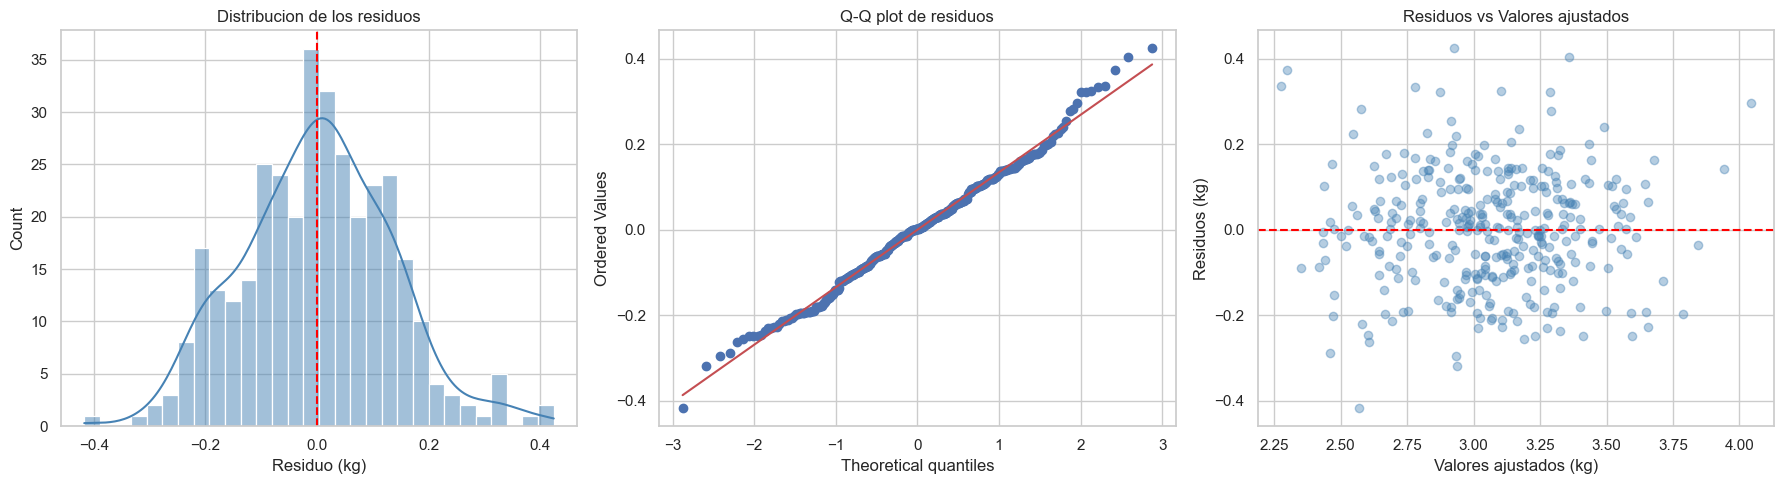

Media de residuos : 0.000000 (debe ser ~0)
Std de residuos   : 0.1342 kg
Asimetria         : 0.1393
Curtosis          : 0.2151
Shapiro-Wilk      : W=0.9936, p=0.1501


In [11]:
residuos = modelo_final.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(residuos, kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribucion de los residuos')
axes[0].set_xlabel('Residuo (kg)')

stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot de residuos')

axes[2].scatter(modelo_final.fittedvalues, residuos, alpha=0.4, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs Valores ajustados')
axes[2].set_xlabel('Valores ajustados (kg)')
axes[2].set_ylabel('Residuos (kg)')

plt.tight_layout()
plt.show()

print(f"Media de residuos : {residuos.mean():.6f} (debe ser ~0)")
print(f"Std de residuos   : {residuos.std():.4f} kg")
print(f"Asimetria         : {residuos.skew():.4f}")
print(f"Curtosis          : {residuos.kurtosis():.4f}")

stat_sw, p_sw = stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=42))
print(f"Shapiro-Wilk      : W={stat_sw:.4f}, p={p_sw:.4f}")


**Caracteristicas de los residuos:**

Para que el modelo de regresion lineal sea valido, los residuos deben cumplir:

1. **Media cero**: la media de los residuos debe ser aproximadamente 0.
2. **Distribucion aproximadamente normal**: verificable con el histograma y el Q-Q plot.
3. **Homocedasticidad**: los residuos no deben mostrar patrones sistematicos al graficarse
   contra los valores ajustados.

Si los residuos presentan sesgo pronunciado o los puntos del Q-Q plot se desvian
significativamente de la linea diagonal, el supuesto de normalidad no se cumple del todo,
aunque la regresion lineal es robusta a desviaciones moderadas con muestras grandes.